# Raw QCL image → gold reference → reflectance

This notebook stops at the reflectance stage. It does not perform baseline correction or absorbance calculation.

It shows three parts:

1. **Raw images for all selected wavenumbers in the specified patterns**, with the brightest `n_reference_pixels` marked as the pixels used to calculate `I_goldref`
2. **`I_goldref` vs. pattern number**
3. **Reflectance images for all selected wavenumbers in the specified patterns**

The definitions used here are:

\[
I_{goldref} = \text{mean of the brightest } N \text{ pixels}
\]

\[
R = \frac{I_{raw}}{I_{goldref}}
\]


## 1. Setup

In [30]:
%matplotlib widget

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qcl_analysis.io import load_qcl_csv
from qcl_analysis.reflectance import (
    calculate_gold_reference,
    calculate_reflectance,
    get_brightest_pixel_indices,
)


Modify the parameters below:

- `stacks_dir`: path to the `stacks` folder containing `pattern0`, `pattern1`, ...
- `patterns_to_show`: patterns to inspect in detail
- `expected_wavenumbers`: wavenumbers to display
- `n_reference_pixels`: number of brightest pixels used to calculate `I_goldref`


In [31]:
# ===== User settings =====
stacks_dir = Path(
    "/Users/ethanjiang/Documents/Cornell/Research/DIY Incubator/Data/A431_04222026_QCL/2026-04-22_021/stacks"
)

patterns_to_show = [
    "pattern5",
    "pattern100",
]

expected_wavenumbers = [1600, 1655, 1750]
n_reference_pixels = 100


## 2. Helper functions

In [32]:
PATTERN_REGEX = re.compile(r"^pattern(\d+)$")


def extract_pattern_number(pattern_name: str) -> int:
    match = PATTERN_REGEX.match(pattern_name)
    if not match:
        raise ValueError(f"Invalid pattern name: {pattern_name}")
    return int(match.group(1))


def get_image_path(stacks_dir: Path, pattern: str, wavenumber: int) -> Path:
    return stacks_dir / pattern / f"lineScan_{wavenumber}_0invcm.csv"


def load_image_bundle(stacks_dir: Path, pattern: str, wavenumber: int, n_pixels: int) -> dict:
    path = get_image_path(stacks_dir, pattern, wavenumber)
    image = load_qcl_csv(path)

    y_idx, x_idx, _ = get_brightest_pixel_indices(image, n_pixels=n_pixels)
    i_goldref = calculate_gold_reference(image, n_pixels=n_pixels)
    reflectance = calculate_reflectance(image, i_goldref)

    return {
        "pattern": pattern,
        "frame": extract_pattern_number(pattern),
        "wavenumber": int(wavenumber),
        "path": path,
        "image": image,
        "x_idx": x_idx,
        "y_idx": y_idx,
        "i_goldref": float(i_goldref),
        "reflectance": reflectance,
    }


def collect_goldref_table(
    stacks_dir: Path,
    expected_wavenumbers: list[int],
    n_pixels: int,
) -> pd.DataFrame:
    """Collect I_goldref values for all valid pattern folders."""

    records = []

    pattern_dirs = [
        path
        for path in stacks_dir.iterdir()
        if path.is_dir()
        and PATTERN_REGEX.match(path.name)
    ]

    pattern_dirs = sorted(
        pattern_dirs,
        key=lambda path: extract_pattern_number(path.name),
    )

    for pattern_dir in pattern_dirs:
        pattern = pattern_dir.name

        for wn in expected_wavenumbers:
            path = get_image_path(
                stacks_dir,
                pattern,
                wn,
            )

            if not path.is_file():
                continue

            image = load_qcl_csv(path)

            i_goldref = calculate_gold_reference(
                image,
                n_pixels=n_pixels,
            )

            records.append(
                {
                    "pattern": pattern,
                    "frame": extract_pattern_number(pattern),
                    "wavenumber": int(wn),
                    "path": str(path),
                    "i_goldref": float(i_goldref),
                    "n_reference_pixels": int(n_pixels),
                }
            )

    if not records:
        raise ValueError(
            "No valid QCL image files were found."
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            [
                "frame",
                "wavenumber",
            ]
        )
        .reset_index(drop=True)
    )


## 3. Inspect selected patterns: raw images + brightest pixels

In [33]:
selected_bundles = []

for pattern in patterns_to_show:
    for wn in expected_wavenumbers:
        selected_bundles.append(
            load_image_bundle(
                stacks_dir=stacks_dir,
                pattern=pattern,
                wavenumber=wn,
                n_pixels=n_reference_pixels,
            )
        )

len(selected_bundles)


6

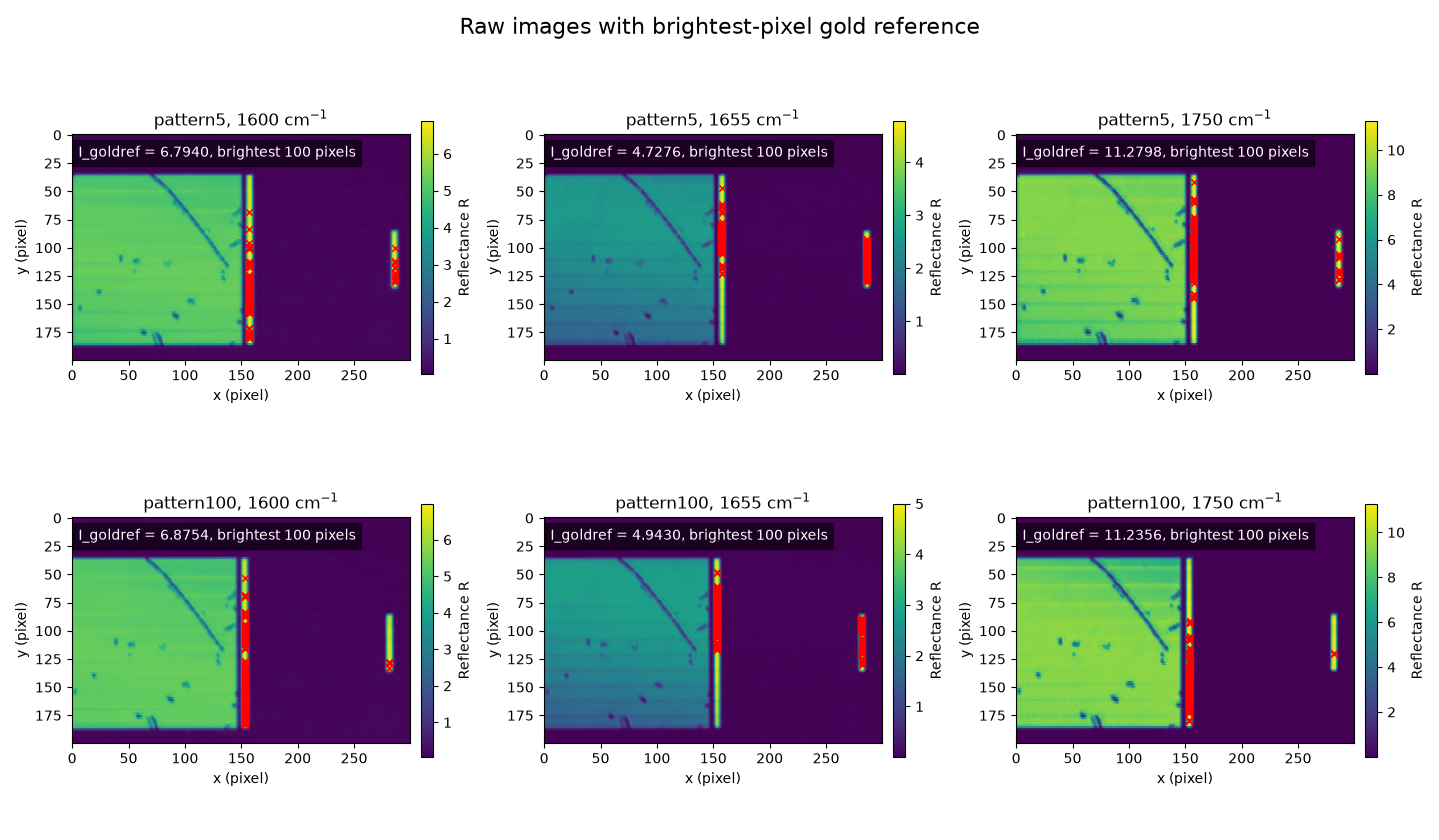

In [34]:
n_rows = len(patterns_to_show)
n_cols = len(expected_wavenumbers)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.2 * n_rows),
    squeeze=False,
)

for row_idx, pattern in enumerate(patterns_to_show):
    for col_idx, wn in enumerate(expected_wavenumbers):
        ax = axes[row_idx, col_idx]

        bundle = next(
            b for b in selected_bundles
            if b["pattern"] == pattern and b["wavenumber"] == wn
        )

        image = bundle["image"]
        x_idx = bundle["x_idx"]
        y_idx = bundle["y_idx"]
        i_goldref = bundle["i_goldref"]

        im = ax.imshow(image, origin="upper")
        ax.scatter(
            x_idx,
            y_idx,
            marker="x",
            c="red",
            s=22,
            linewidths=1.1,
        )
        ax.set_title(f"{pattern}, {wn} cm$^{{-1}}$")
        ax.set_xlabel("x (pixel)")
        ax.set_ylabel("y (pixel)")

        ax.text(
            0.02,
            0.95,
            f"I_goldref = {i_goldref:.4f}, brightest {n_reference_pixels} pixels",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, pad=4),
        )

        fig.colorbar(
            im,
            ax=ax,
            label="Reflectance R",
            fraction=0.035,
            pad=0.03,
        )

fig.suptitle("Raw images with brightest-pixel gold reference", fontsize=16)
fig.tight_layout()
plt.show()


## 4. Build a table of `I_goldref` for all patterns

In [35]:
goldref_table = collect_goldref_table(
    stacks_dir=stacks_dir,
    expected_wavenumbers=expected_wavenumbers,
    n_pixels=n_reference_pixels,
)

goldref_table.head(20)


,pattern,frame,wavenumber,path,i_goldref,n_reference_pixels
0,pattern0,0,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.782312,100
1,pattern0,0,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.683966,100
2,pattern0,0,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,8.570483,100
3,pattern1,1,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.794790,100
4,pattern1,1,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.703976,100
5,pattern1,1,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,10.609916,100
6,pattern2,2,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.604422,100
7,pattern2,2,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.712170,100
8,pattern2,2,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,11.241329,100
9,pattern3,3,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.794879,100


## 5. Plot `I_goldref` vs. pattern number

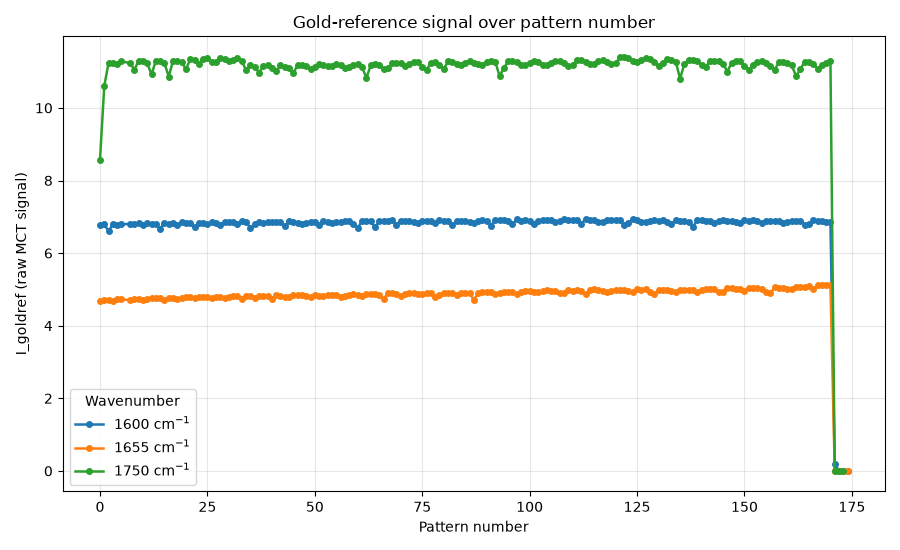

In [36]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for wn in expected_wavenumbers:
    sub = goldref_table[goldref_table["wavenumber"] == wn].sort_values("frame")
    ax.plot(
        sub["frame"],
        sub["i_goldref"],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=f"{wn} cm$^{{-1}}$",
    )

ax.set_title("Gold-reference signal over pattern number")
ax.set_xlabel("Pattern number")
ax.set_ylabel("I_goldref (raw MCT signal)")
ax.grid(True, alpha=0.3)
ax.legend(title="Wavenumber")
fig.tight_layout()
plt.show()


## 6. Reflectance images for the selected patterns

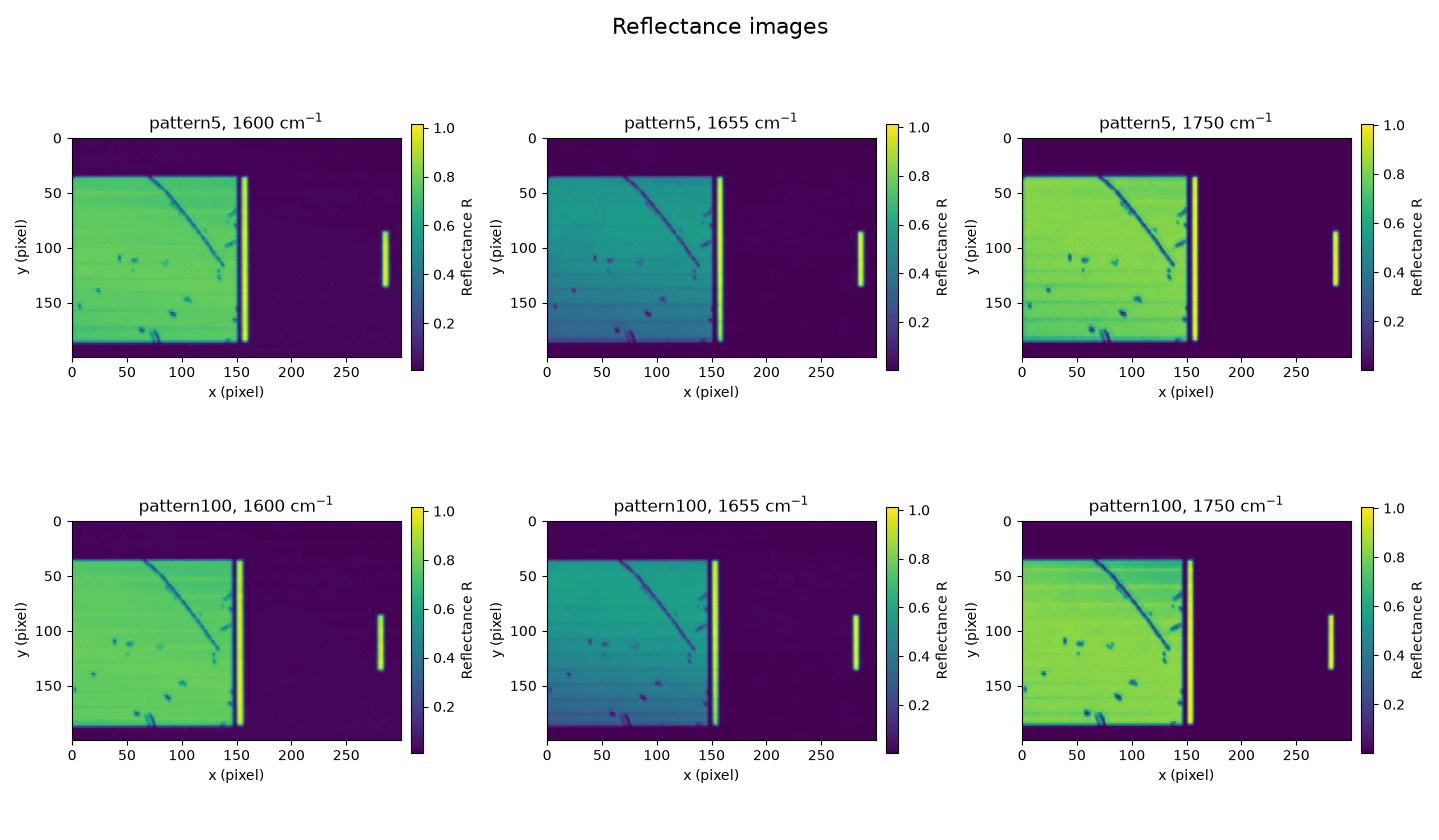

In [37]:
n_rows = len(patterns_to_show)
n_cols = len(expected_wavenumbers)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 4.2 * n_rows),
    squeeze=False,
)

for row_idx, pattern in enumerate(patterns_to_show):
    for col_idx, wn in enumerate(expected_wavenumbers):
        ax = axes[row_idx, col_idx]

        bundle = next(
            b for b in selected_bundles
            if b["pattern"] == pattern and b["wavenumber"] == wn
        )

        reflectance = bundle["reflectance"]
        i_goldref = bundle["i_goldref"]

        im = ax.imshow(reflectance, origin="upper")
        ax.set_title(f"{pattern}, {wn} cm$^{{-1}}$")
        ax.set_xlabel("x (pixel)")
        ax.set_ylabel("y (pixel)")

        # ax.text(
        #     0.02,
        #     0.98,
        #     f"I_goldref = {i_goldref:.4f}",
        #     transform=ax.transAxes,
        #     ha="left",
        #     va="top",
        #     fontsize=10,
        #     color="white",
        #     bbox=dict(facecolor="black", alpha=0.6, pad=4),
        # )

        fig.colorbar(
            im,
            ax=ax,
            label="Reflectance R",
            fraction=0.035,
            pad=0.03,
        )

fig.suptitle("Reflectance images", fontsize=16)
fig.tight_layout()
plt.show()


## 7. Optional: inspect one selected pattern as a small table

In [38]:
goldref_table[goldref_table["pattern"].isin(patterns_to_show)].reset_index(drop=True)


,pattern,frame,wavenumber,path,i_goldref,n_reference_pixels
0,pattern5,5,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.794029,100
1,pattern5,5,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.727589,100
2,pattern5,5,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,11.279800,100
3,pattern100,100,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.875357,100
4,pattern100,100,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.943029,100
5,pattern100,100,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,11.235626,100
